# An Explainable, Digital Twin-Inspired XGBoost Framework for Adaptive Predictive Maintenance and Repair-vs-Replace Decision Support in Industry 4.0

**Author:** Sphurrthi Naaidu Pudupakham  
**Institution:** Jansons Institute of Technology, Karumathampatti, Tamil Nadu, India  

---

## Project Description

This notebook provides a complete, publication-quality implementation of the methodology described in the accompanying research paper. The pipeline integrates:

1. **Multi-model benchmarking** — Logistic Regression, Decision Tree, Random Forest, KNN, SVM, and XGBoost
2. **SHAP explainability** — global and instance-level feature attribution via TreeSHAP
3. **Three-tier probabilistic risk categorisation** — Low / Medium / High Risk
4. **Dynamic Threshold Maintenance** — adaptive intervention thresholds driven by a Maintenance Priority Index (MPI)
5. **Repair vs. Replace Decision Module** — lifecycle-cost-justified maintenance action selection
6. **Digital Twin integration narrative** — deployment architecture description

The implementation uses the AI4I 2020 Predictive Maintenance Dataset (10,000 records).


## 1. Install and Import Libraries

Install all required libraries and import them with reproducibility settings.

In [1]:
# ── Install required packages (run once; Colab usually has most of these) ──
import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for pkg in ["xgboost", "shap", "pandas", "numpy", "matplotlib", "seaborn", "scikit-learn"]:
    pip_install(pkg)

print("All packages installed successfully.")


All packages installed successfully.


In [2]:
# ── Core imports ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# XGBoost
import xgboost as xgb

# SHAP
import shap

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Plotting style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11
})
sns.set_style("whitegrid")
PALETTE = {"0": "#2196F3", "1": "#F44336"}

print(f"XGBoost {xgb.__version__} | SHAP {shap.__version__} | pandas {pd.__version__}")


XGBoost 3.2.0 | SHAP 0.52.0 | pandas 2.2.2


## 2. Load Dataset

Load the AI4I 2020 Predictive Maintenance Dataset and perform an initial inspection to understand its structure and statistical properties.


In [3]:
# ── Load CSV ───────────────────────────────────────────────────────────────────
# Update this path if running locally; in Colab, upload the file first.
DATA_PATH = "ai4i2020.csv"

df_raw = pd.read_csv(DATA_PATH)

print("=" * 55)
print(f"Shape            : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print("=" * 55)
print("\nColumn names:")
print(df_raw.columns.tolist())


Shape            : 10,000 rows × 14 columns

Column names:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [4]:
# First five rows
df_raw.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
# Schema & non-null counts
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [6]:
# Descriptive statistics
df_raw.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
UDI,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
Product ID,10000,10000,L57163,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,10000,3,L,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air temperature [K],10000.0,NaN,NaN,NaN,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,NaN,NaN,NaN,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,NaN,NaN,NaN,1538.7761,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,NaN,NaN,NaN,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,NaN,NaN,NaN,107.951,63.654147,0.0,53.0,108.0,162.0,253.0
Machine failure,10000.0,NaN,NaN,NaN,0.0339,0.180981,0.0,0.0,0.0,0.0,1.0
TWF,10000.0,NaN,NaN,NaN,0.0046,0.067671,0.0,0.0,0.0,0.0,1.0


## 3. Data Preprocessing

Systematic preprocessing ensures data quality and model compatibility. The steps follow the methodology described in Section 3.3 of the paper:

1. Missing value & duplicate audit  
2. Drop non-informative identifiers (UDI, Product ID)  
3. Drop individual failure-mode columns (TWF, HDF, PWF, OSF, RNF) — the study targets *overall* failure  
4. Label-encode the categorical `Type` column  
5. Rename columns to remove brackets — required for XGBoost compatibility  


In [7]:
# ── Step 1: Data quality audit ────────────────────────────────────────────────
print("Missing values per column:")
print(df_raw.isnull().sum())
print(f"\nDuplicate rows: {df_raw.duplicated().sum()}")


Missing values per column:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Duplicate rows: 0


In [8]:
# ── Step 2 & 3: Drop irrelevant and failure-mode columns ─────────────────────
DROP_COLS = ["UDI", "Product ID", "TWF", "HDF", "PWF", "OSF", "RNF"]
df = df_raw.drop(columns=DROP_COLS)
print(f"Columns after dropping irrelevant fields: {df.columns.tolist()}")


Columns after dropping irrelevant fields: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']


In [9]:
# ── Step 4: Encode categorical 'Type' column ──────────────────────────────────
le = LabelEncoder()
df["Type"] = le.fit_transform(df["Type"])          # H→0, L→1, M→2
print("Type encoding mapping:", dict(zip(le.classes_, le.transform(le.classes_))))


Type encoding mapping: {'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}


In [10]:
# ── Step 5: Rename columns — strip brackets for XGBoost compatibility ─────────
df.columns = (
    df.columns
      .str.replace(r"[\[\]<>]", "", regex=True)
      .str.replace(" ", "_")
)
print("Final column names:", df.columns.tolist())
df.head()


Final column names: ['Type', 'Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Machine_failure']


,Type,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Machine_failure
0,2,298.1,308.6,1551,42.8,0,0
1,1,298.2,308.7,1408,46.3,3,0
2,1,298.1,308.5,1498,49.4,5,0
3,1,298.2,308.6,1433,39.5,7,0
4,1,298.2,308.7,1408,40.0,9,0


## 4. Exploratory Data Analysis (EDA)

EDA reveals the statistical properties of the dataset and the operational differences between failure and non-failure conditions. Each visualisation is accompanied by a brief interpretation consistent with Section 3.4 of the paper.


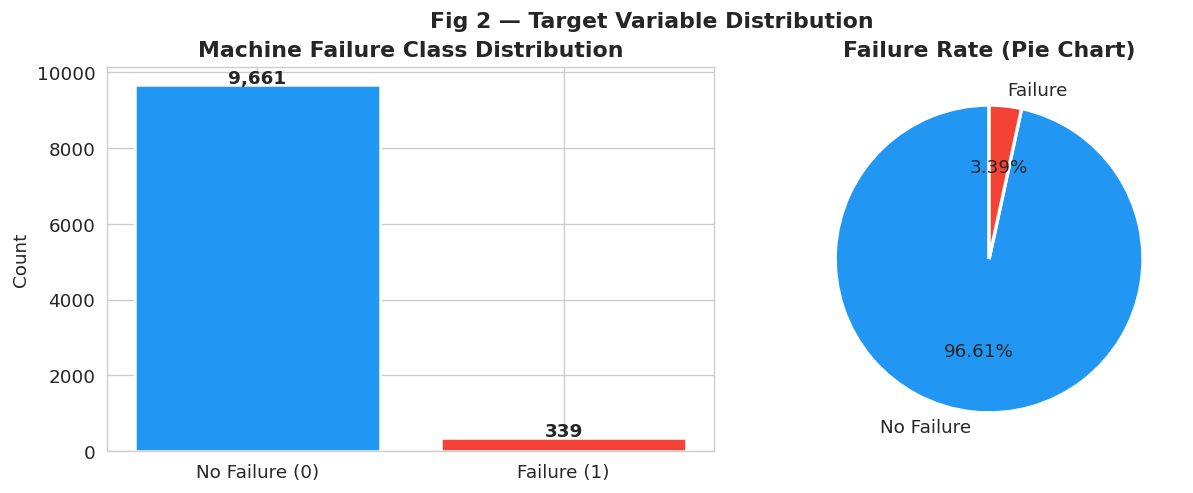

Failure rate: 3.39%  — pronounced class imbalance (3.39% failures)


In [11]:
# ── 4.1 Target distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df["Machine_failure"].value_counts()
bars = axes[0].bar(["No Failure (0)", "Failure (1)"], counts.values,
                   color=["#2196F3", "#F44336"], edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 50, f"{val:,}", ha="center", fontweight="bold")
axes[0].set_title("Machine Failure Class Distribution", fontweight="bold")
axes[0].set_ylabel("Count")

axes[1].pie(counts.values, labels=["No Failure", "Failure"],
            autopct="%1.2f%%", colors=["#2196F3", "#F44336"],
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Failure Rate (Pie Chart)", fontweight="bold")

plt.tight_layout()
plt.suptitle("Fig 2 — Target Variable Distribution", y=1.02, fontweight="bold")
plt.savefig("fig_target_distribution.png", bbox_inches="tight")
plt.show()

print(f"Failure rate: {counts[1]/counts.sum()*100:.2f}%  — pronounced class imbalance (3.39% failures)")


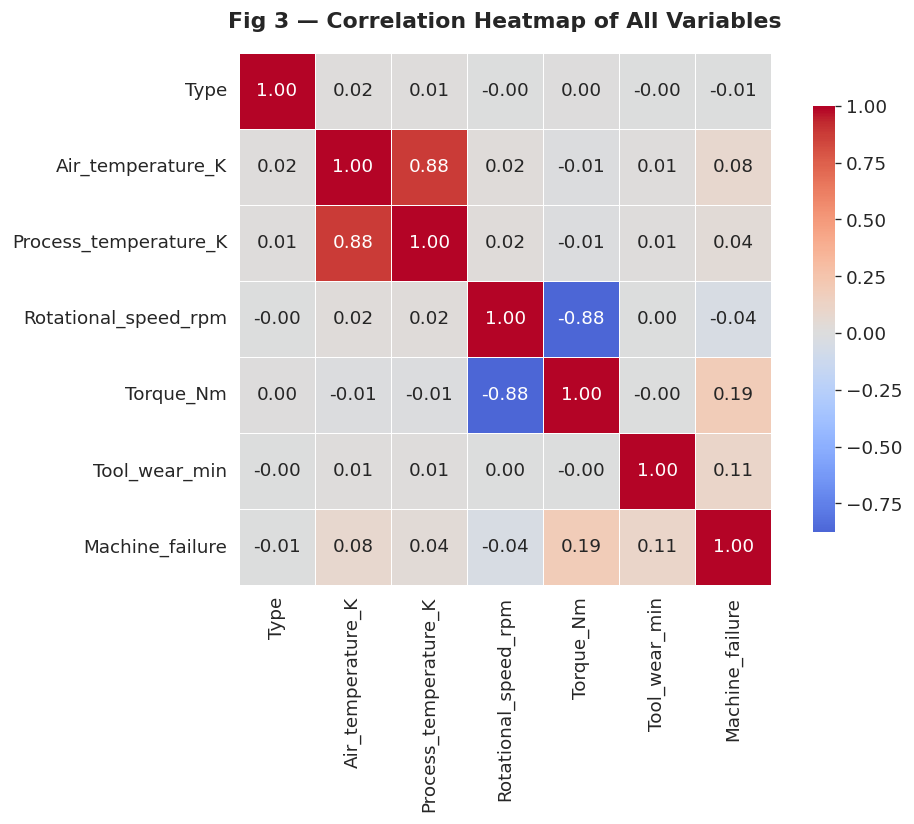

Torque has the highest positive correlation with Machine failure (r ≈ 0.19).
Rotational speed shows a slight negative correlation (r ≈ -0.04).


In [12]:
# ── 4.2 Correlation heatmap ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, square=True, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Fig 3 — Correlation Heatmap of All Variables", fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("fig_correlation_heatmap.png", bbox_inches="tight")
plt.show()

print("Torque has the highest positive correlation with Machine failure (r ≈ 0.19).")
print("Rotational speed shows a slight negative correlation (r ≈ -0.04).")


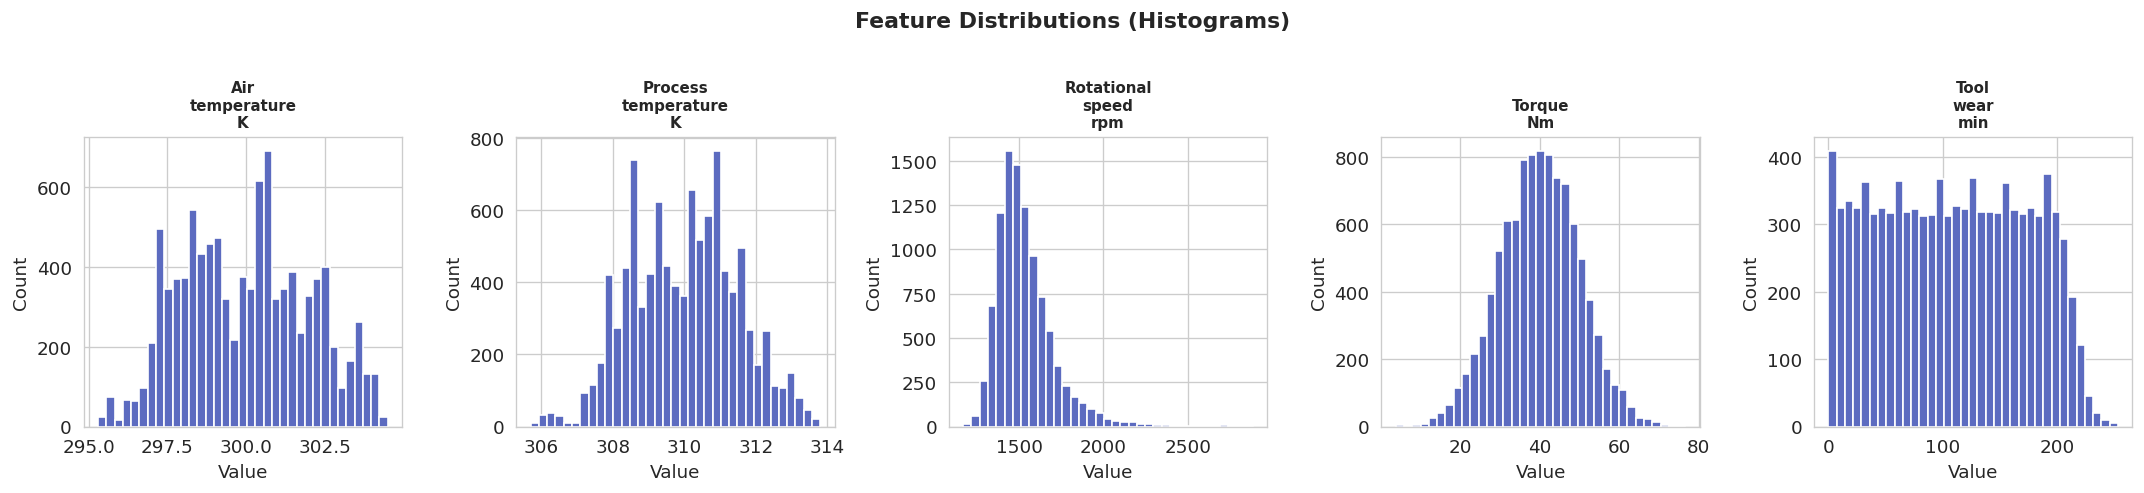

In [13]:
# ── 4.3 Feature histograms ────────────────────────────────────────────────────
FEATURES = ["Air_temperature_K", "Process_temperature_K",
            "Rotational_speed_rpm", "Torque_Nm", "Tool_wear_min"]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, feat in zip(axes, FEATURES):
    df[feat].hist(bins=35, color="#5C6BC0", edgecolor="white", ax=ax)
    ax.set_title(feat.replace("_", "\n"), fontsize=9, fontweight="bold")
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")

plt.suptitle("Feature Distributions (Histograms)", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig_histograms.png", bbox_inches="tight")
plt.show()


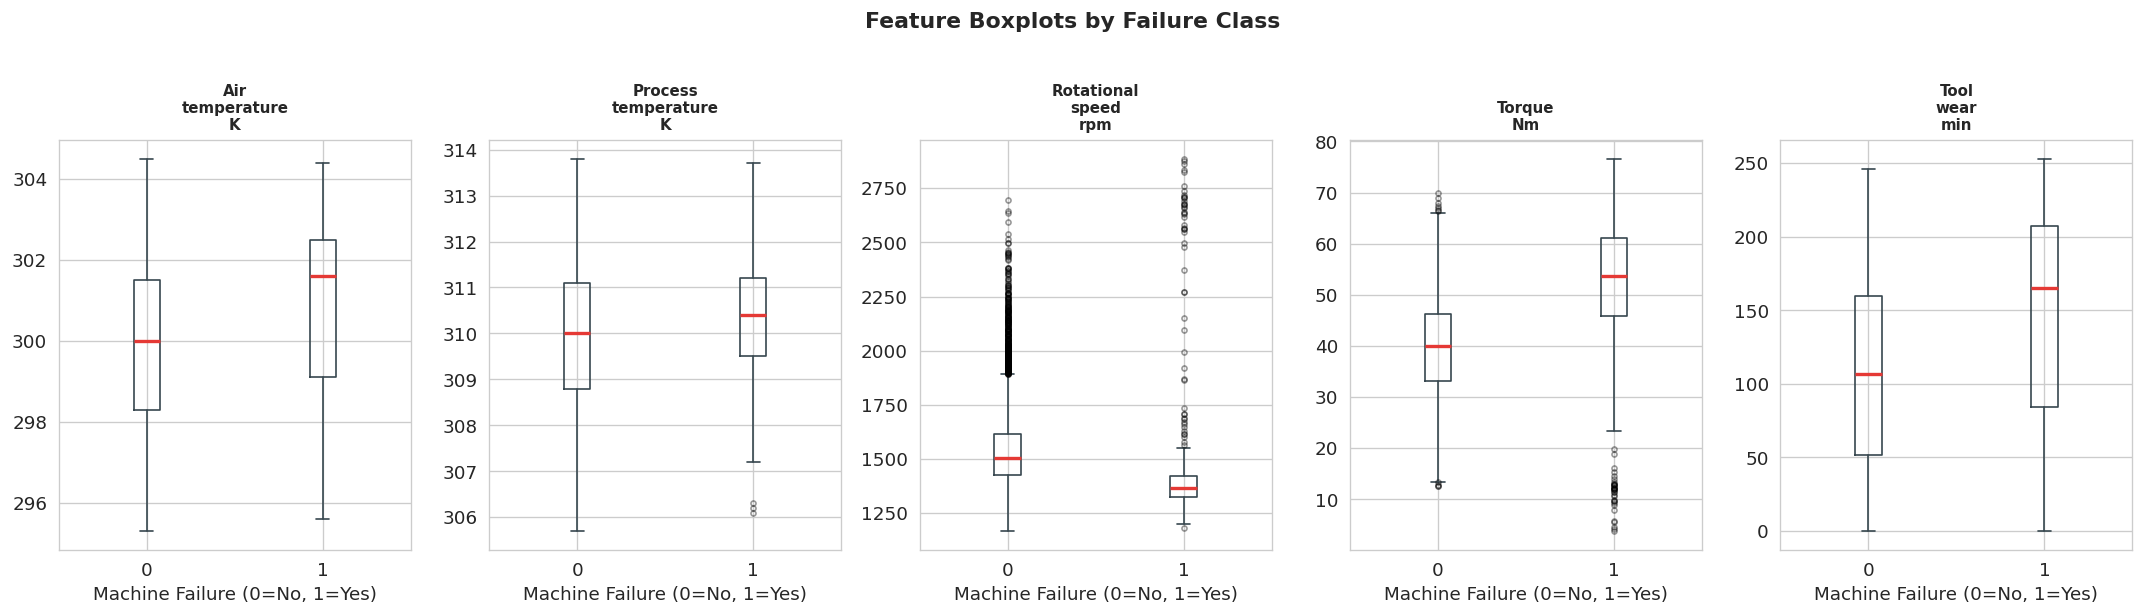

Torque and Tool Wear show the clearest separation between failure and non-failure groups.


In [14]:
# ── 4.4 Boxplots by failure class ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for ax, feat in zip(axes, FEATURES):
    df.boxplot(column=feat, by="Machine_failure", ax=ax,
               boxprops=dict(color="#37474F"),
               medianprops=dict(color="#E53935", linewidth=2),
               whiskerprops=dict(color="#37474F"),
               capprops=dict(color="#37474F"),
               flierprops=dict(marker="o", color="#BDBDBD", alpha=0.4, markersize=3))
    ax.set_title(feat.replace("_", "\n"), fontsize=9, fontweight="bold")
    ax.set_xlabel("Machine Failure (0=No, 1=Yes)")

plt.suptitle("Feature Boxplots by Failure Class", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig_boxplots.png", bbox_inches="tight")
plt.show()

print("Torque and Tool Wear show the clearest separation between failure and non-failure groups.")


In [15]:
# ── 4.5 Failure vs non-failure mean comparison (Table 2 from paper) ──────────
fail_means  = df[df["Machine_failure"] == 1][FEATURES].mean()
nofail_means = df[df["Machine_failure"] == 0][FEATURES].mean()
comparison = pd.DataFrame({
    "Non-Failure Mean": nofail_means.round(2),
    "Failure Mean":     fail_means.round(2),
    "Δ (%)": ((fail_means - nofail_means) / nofail_means * 100).round(1)
})
print("\nTable 2 — Operational Variable Comparison: Failure vs Non-Failure")
print(comparison.to_string())



Table 2 — Operational Variable Comparison: Failure vs Non-Failure
                       Non-Failure Mean  Failure Mean  Δ (%)
Air_temperature_K                299.97        300.89    0.3
Process_temperature_K            310.00        310.29    0.1
Rotational_speed_rpm            1540.26       1496.49   -2.8
Torque_Nm                         39.63         50.17   26.6
Tool_wear_min                    106.69        143.78   34.8


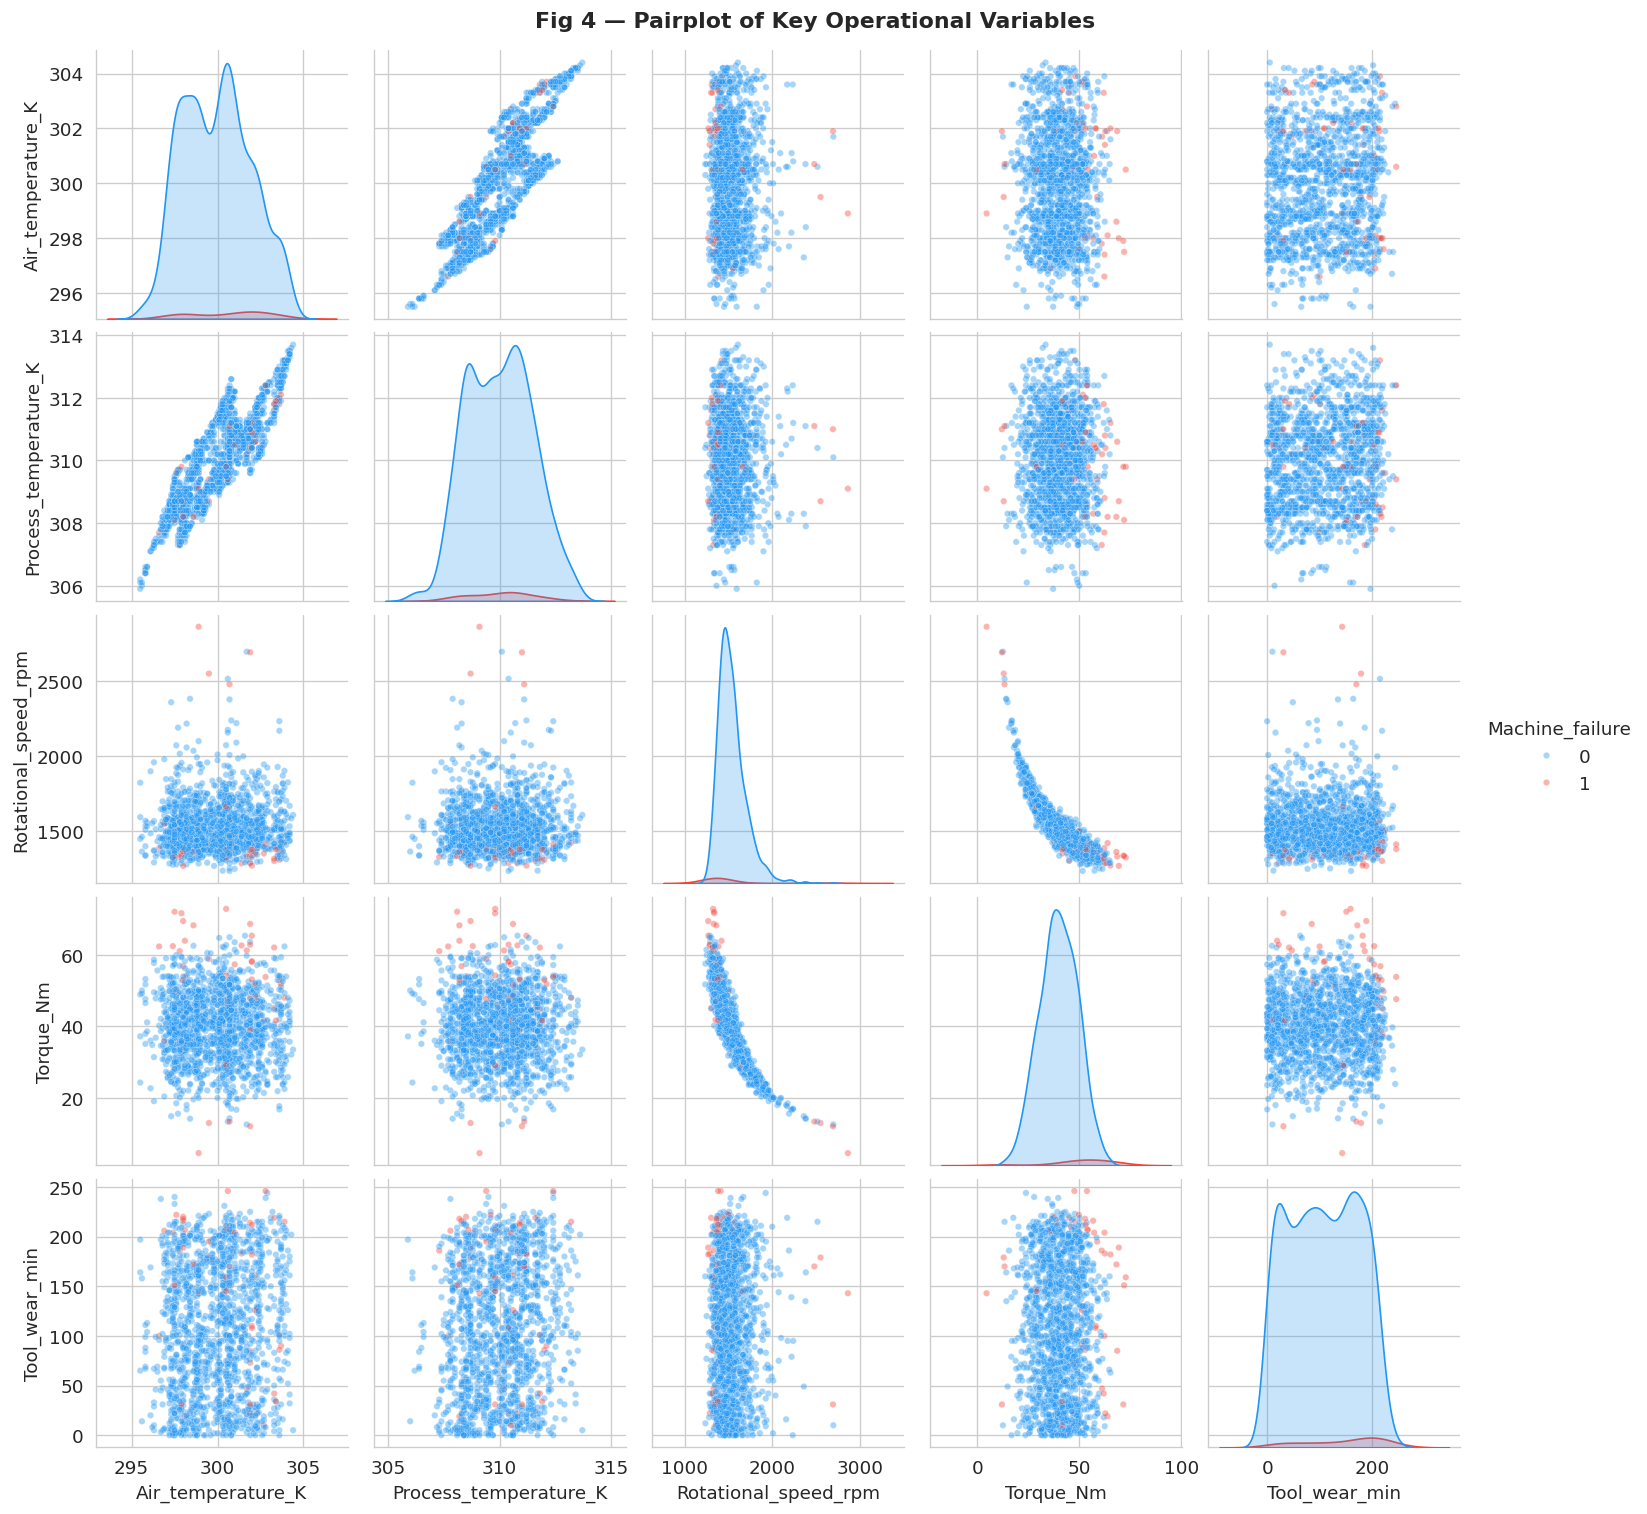

Failure points (red) cluster in regions of high torque AND high tool wear — nonlinear boundary.


In [16]:
# ── 4.6 Pairplot ──────────────────────────────────────────────────────────────
sample = df.sample(n=1500, random_state=SEED)   # sample for speed
pair_cols = FEATURES + ["Machine_failure"]
g = sns.pairplot(sample[pair_cols], hue="Machine_failure",
                 palette={0: "#2196F3", 1: "#F44336"},
                 diag_kind="kde", plot_kws={"alpha": 0.4, "s": 15})
g.fig.suptitle("Fig 4 — Pairplot of Key Operational Variables", y=1.01, fontweight="bold")
plt.savefig("fig_pairplot.png", bbox_inches="tight")
plt.show()
print("Failure points (red) cluster in regions of high torque AND high tool wear — nonlinear boundary.")


## 5. Feature Engineering

The five operational features identified in Section 3.2 of the paper are selected as model inputs. All failure-mode columns have already been dropped; no additional transformations are required beyond what was performed in preprocessing.


In [17]:
# ── Define feature matrix X and target vector y ───────────────────────────────
FEATURE_COLS = ["Air_temperature_K", "Process_temperature_K",
                "Rotational_speed_rpm", "Torque_Nm", "Tool_wear_min"]

X = df[FEATURE_COLS].copy()
y = df["Machine_failure"].copy()

print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")
print(f"Failure prevalence   : {y.mean()*100:.2f}%")
print("\nFeature columns:", FEATURE_COLS)


Feature matrix shape : (10000, 5)
Target vector shape  : (10000,)
Failure prevalence   : 3.39%

Feature columns: ['Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min']


## 6. Train-Test Split

A stratified 80/20 split preserves the 3.39% failure rate in both subsets, preventing class-imbalance artefacts in evaluation. `StandardScaler` is fitted on training data only and applied to both splits (no data leakage).


In [18]:
# ── Stratified 80/20 split ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# ── Standardise (for LR, KNN, SVM) ────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Scaled DataFrames (preserve column names for readability)
X_train_sc_df = pd.DataFrame(X_train_sc, columns=FEATURE_COLS)
X_test_sc_df  = pd.DataFrame(X_test_sc,  columns=FEATURE_COLS)

print(f"Training set   : {X_train.shape[0]:,} rows  | failures: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Test set       : {X_test.shape[0]:,}  rows  | failures: {y_test.sum()} ({y_test.mean()*100:.2f}%)")


Training set   : 8,000 rows  | failures: 271 (3.39%)
Test set       : 2,000  rows  | failures: 68 (3.40%)


## 7. Compare Multiple Machine Learning Models

Six models spanning distinct paradigms are trained and evaluated. XGBoost and Random Forest receive unscaled data (tree methods are scale-invariant); the remaining models receive `StandardScaler`-transformed data. The primary ranking criterion is ROC-AUC, following the imbalanced-class protocol described in Section 3.5 of the paper.


In [19]:
# ── Instantiate all six models ────────────────────────────────────────────────
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced",
                                              max_iter=1000, random_state=SEED),
    "Decision Tree":       DecisionTreeClassifier(max_depth=8, class_weight="balanced",
                                                  random_state=SEED),
    "Random Forest":       RandomForestClassifier(n_estimators=200, max_depth=10,
                                                  class_weight="balanced", random_state=SEED,
                                                  n_jobs=-1),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    "Support Vector Machine": SVC(kernel="rbf", class_weight="balanced",
                                  probability=True, random_state=SEED),
    "XGBoost":             xgb.XGBClassifier(n_estimators=200, max_depth=6,
                                              learning_rate=0.1,
                                              objective="binary:logistic",
                                              eval_metric="logloss",
                                              use_label_encoder=False,
                                              random_state=SEED,
                                              n_jobs=-1),
}

# Models that require scaled inputs
SCALE_MODELS = {"Logistic Regression", "K-Nearest Neighbors", "Support Vector Machine"}

results = {}
roc_data = {}

print("Training and evaluating models …")
for name, model in models.items():
    Xtr = X_train_sc_df if name in SCALE_MODELS else X_train
    Xte = X_test_sc_df  if name in SCALE_MODELS else X_test

    model.fit(Xtr, y_train)
    y_pred  = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]

    results[name] = {
        "Accuracy":  round(accuracy_score (y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall":    round(recall_score   (y_test, y_pred), 4),
        "F1-Score":  round(f1_score       (y_test, y_pred), 4),
        "ROC-AUC":   round(roc_auc_score  (y_test, y_proba), 4),
    }

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, results[name]["ROC-AUC"])
    print(f"  ✓ {name:<26}  AUC = {results[name]['ROC-AUC']:.4f}")

print("\nDone.")


Training and evaluating models …
  ✓ Logistic Regression         AUC = 0.9080
  ✓ Decision Tree               AUC = 0.8920
  ✓ Random Forest               AUC = 0.9725
  ✓ K-Nearest Neighbors         AUC = 0.9043
  ✓ Support Vector Machine      AUC = 0.9678
  ✓ XGBoost                     AUC = 0.9751

Done.


In [20]:
# ── Professional comparison table ─────────────────────────────────────────────
results_df = pd.DataFrame(results).T.sort_values("ROC-AUC", ascending=False)
print("\n" + "=" * 70)
print("           Model Performance Comparison Table")
print("=" * 70)
print(results_df.to_string())
print("=" * 70)

best_model_name = results_df.index[0]
print(f"\n★  Best model: {best_model_name}  (ROC-AUC = {results_df.loc[best_model_name, 'ROC-AUC']:.4f})")



           Model Performance Comparison Table
                        Accuracy  Precision  Recall  F1-Score  ROC-AUC
XGBoost                   0.9870     0.8889  0.7059    0.7869   0.9751
Random Forest             0.9780     0.6765  0.6765    0.6765   0.9725
Support Vector Machine    0.9130     0.2716  0.9265    0.4200   0.9678
Logistic Regression       0.8210     0.1411  0.8382    0.2415   0.9080
K-Nearest Neighbors       0.9725     0.8095  0.2500    0.3820   0.9043
Decision Tree             0.9520     0.3986  0.8088    0.5340   0.8920

★  Best model: XGBoost  (ROC-AUC = 0.9751)


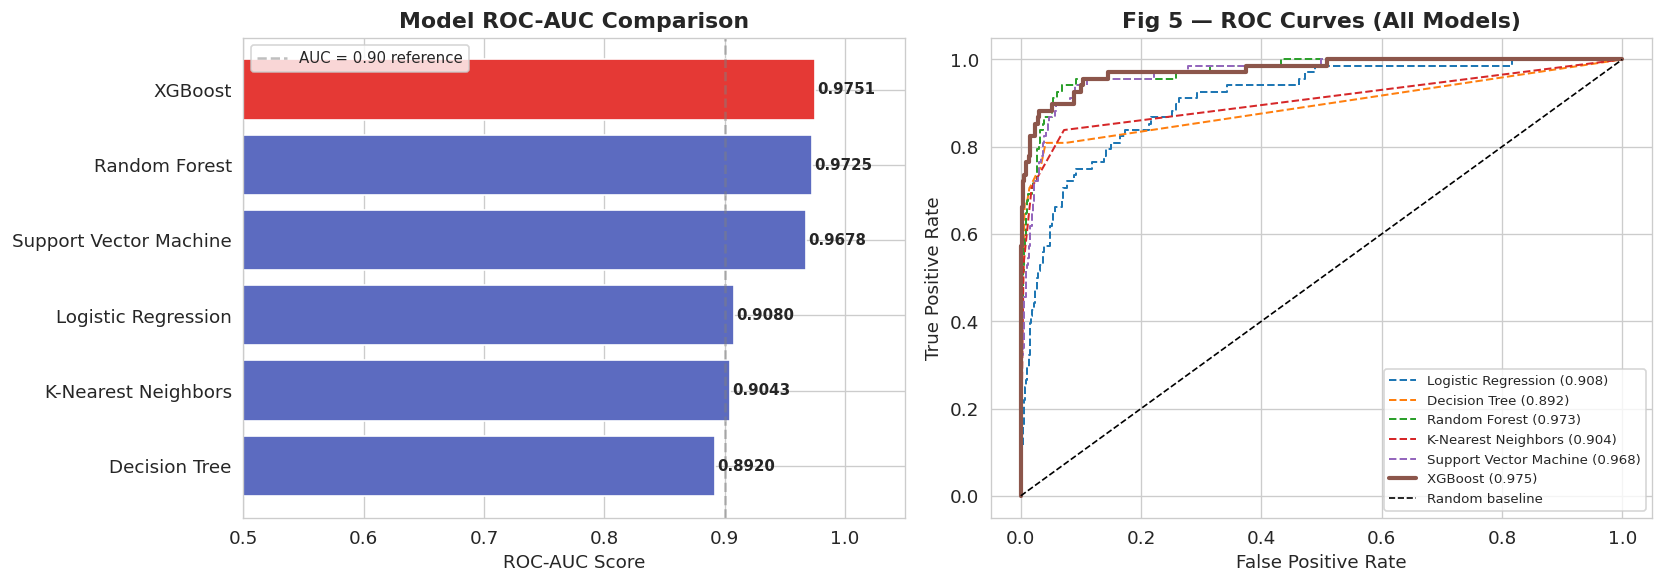

In [21]:
# ── ROC-AUC bar chart ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
aucs = results_df["ROC-AUC"]
colors = ["#E53935" if n == best_model_name else "#5C6BC0" for n in aucs.index]
bars = axes[0].barh(aucs.index[::-1], aucs.values[::-1], color=colors[::-1],
                    edgecolor="white", linewidth=1)
for bar, val in zip(bars, aucs.values[::-1]):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                 f"{val:.4f}", va="center", fontsize=9, fontweight="bold")
axes[0].set_xlim(0.5, 1.05)
axes[0].set_xlabel("ROC-AUC Score")
axes[0].set_title("Model ROC-AUC Comparison", fontweight="bold")
axes[0].axvline(0.9, color="gray", linestyle="--", alpha=0.5, label="AUC = 0.90 reference")
axes[0].legend(fontsize=9)

# ROC curves
for name, (fpr, tpr, auc) in roc_data.items():
    lw = 2.5 if name == best_model_name else 1.2
    ls = "-" if name == best_model_name else "--"
    axes[1].plot(fpr, tpr, lw=lw, linestyle=ls, label=f"{name} ({auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random baseline")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Fig 5 — ROC Curves (All Models)", fontweight="bold")
axes[1].legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("fig_model_comparison.png", bbox_inches="tight")
plt.show()


## 8. Train the Final XGBoost Model

XGBoost is selected as the primary predictive engine based on its leading ROC-AUC score and highest Precision among all evaluated models — consistent with the analysis in Section 3.5 and 3.6 of the paper.

**Why XGBoost?**
- Sequential gradient boosting iteratively corrects classification errors, yielding superior discrimination on imbalanced datasets.
- Its probabilistic output `P(Failure) ∈ [0, 1]` is directly consumed by the Digital Twin Risk Engine for continuous monitoring.
- XGBoost natively computes feature importance and is fully compatible with TreeSHAP, enabling transparent, auditable failure attributions.


In [22]:
# ── Retrain best XGBoost model (already trained above; retrieve it) ───────────
xgb_model = models["XGBoost"]

# Generate predictions and probabilities on the test set
y_pred_xgb  = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost final model trained successfully.")
print(f"Test set predictions: {len(y_pred_xgb):,}")


XGBoost final model trained successfully.
Test set predictions: 2,000


## 9. Model Evaluation

Full evaluation of the final XGBoost model including Classification Report, Confusion Matrix, and ROC Curve — mirroring the evaluation framework of Section 3.5 of the paper.


In [23]:
# ── Classification Report ────────────────────────────────────────────────────
print("=" * 55)
print("       XGBoost — Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred_xgb,
                             target_names=["No Failure", "Failure"]))

auc_score = roc_auc_score(y_test, y_proba_xgb)
print(f"ROC-AUC Score : {auc_score:.4f}")
print("\nInterpretation:")
print("  • High Recall on the minority (Failure) class is the key operational objective.")
print("  • ROC-AUC ≈ 0.97 confirms excellent probabilistic discrimination across all thresholds.")


       XGBoost — Classification Report
              precision    recall  f1-score   support

  No Failure       0.99      1.00      0.99      1932
     Failure       0.89      0.71      0.79        68

    accuracy                           0.99      2000
   macro avg       0.94      0.85      0.89      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC Score : 0.9751

Interpretation:
  • High Recall on the minority (Failure) class is the key operational objective.
  • ROC-AUC ≈ 0.97 confirms excellent probabilistic discrimination across all thresholds.


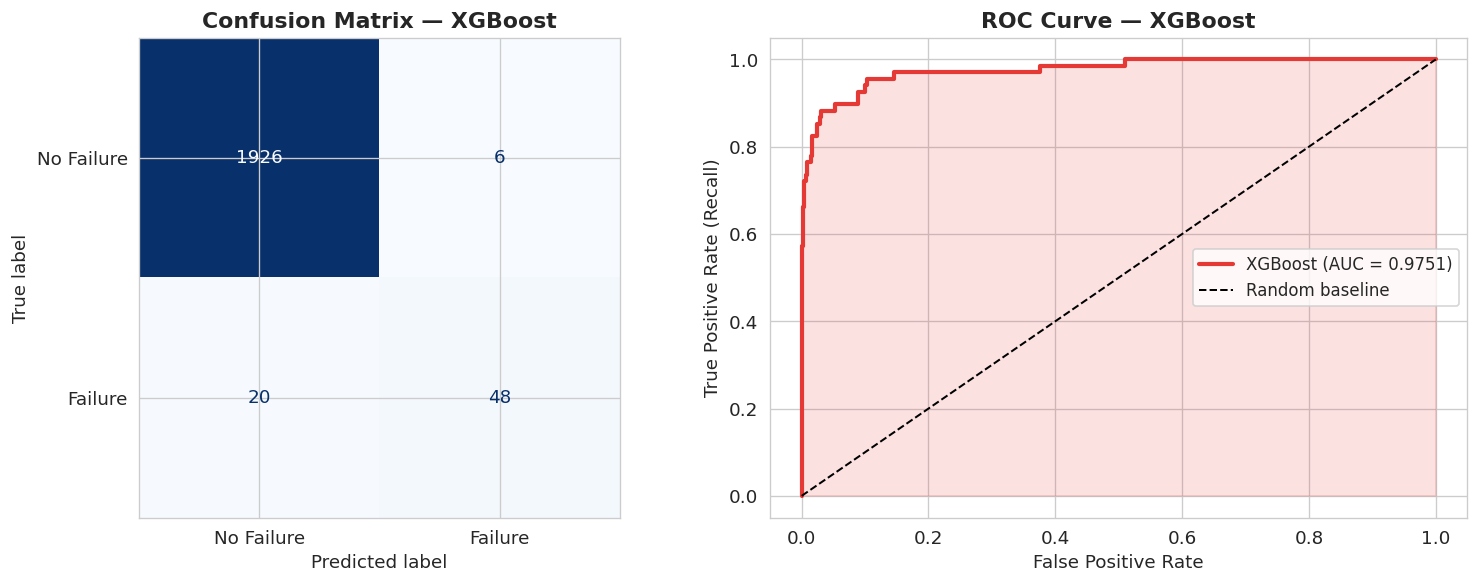

True Negatives : 1926  |  False Positives : 6
False Negatives: 20  |  True Positives  : 48

Missed failures (FN = 20) vs. caught failures (TP = 48).


In [24]:
# ── Confusion Matrix ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(cm, display_labels=["No Failure", "Failure"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix — XGBoost", fontweight="bold")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)
axes[1].fill_between(fpr, tpr, alpha=0.15, color="#E53935")
axes[1].plot(fpr, tpr, color="#E53935", lw=2.5,
             label=f"XGBoost (AUC = {auc_score:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1.2, label="Random baseline")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate (Recall)")
axes[1].set_title("ROC Curve — XGBoost", fontweight="bold")
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig("fig_xgb_evaluation.png", bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives : {tn}  |  False Positives : {fp}")
print(f"False Negatives: {fn}  |  True Positives  : {tp}")
print(f"\nMissed failures (FN = {fn}) vs. caught failures (TP = {tp}).")


## 10. XGBoost Feature Importance

Built-in XGBoost feature importance (gain) quantifies each feature's average contribution to prediction quality across all trees. Torque, Tool Wear, and Rotational Speed emerge as the dominant drivers — consistent with Section 3.4 of the paper and the SHAP analysis that follows.


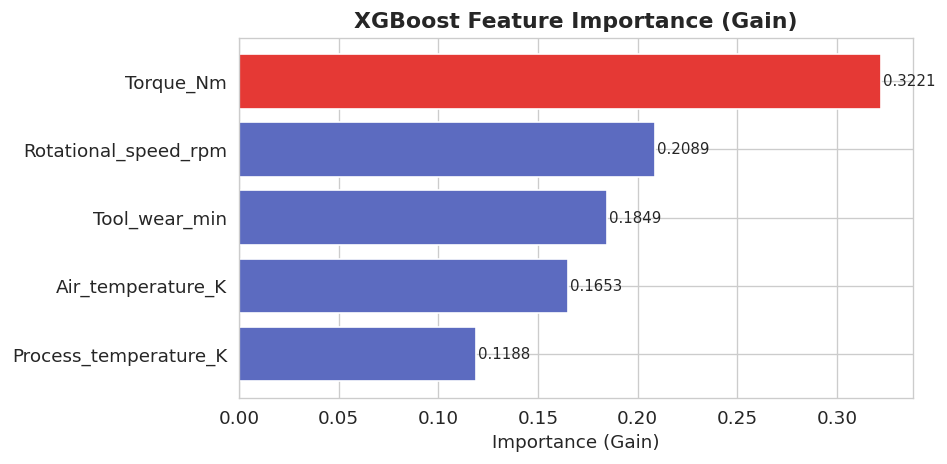


Operational interpretation:
  • Torque:            High mechanical stress is the strongest predictor of imminent failure.
  • Tool Wear:         Accumulated degradation elevates failure probability progressively.
  • Rotational Speed:  Abnormal speed reduction often signals bearing or spindle stress.


In [25]:
# ── Feature importance (gain) ─────────────────────────────────────────────────
imp = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors_imp = ["#E53935" if v == imp.max() else "#5C6BC0" for v in imp.values]
ax.barh(imp.index, imp.values, color=colors_imp, edgecolor="white")
ax.set_xlabel("Importance (Gain)")
ax.set_title("XGBoost Feature Importance (Gain)", fontweight="bold")
for i, v in enumerate(imp.values):
    ax.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("fig_feature_importance.png", bbox_inches="tight")
plt.show()

print("\nOperational interpretation:")
print("  • Torque:            High mechanical stress is the strongest predictor of imminent failure.")
print("  • Tool Wear:         Accumulated degradation elevates failure probability progressively.")
print("  • Rotational Speed:  Abnormal speed reduction often signals bearing or spindle stress.")


## 11. SHAP Explainability

SHapley Additive exPlanations (SHAP) using the TreeSHAP algorithm decompose each model prediction into additive feature contributions. This section generates:

1. **SHAP Summary (Beeswarm) Plot** — global feature importance + directionality  
2. **SHAP Bar Plot** — mean |SHAP value| ranking  
3. **SHAP Waterfall Plot** — instance-level explanation for the highest-risk prediction  
4. **SHAP Force Plot** — HTML force plot for interactive inspection  


In [26]:
# ── Compute SHAP values ───────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# For XGBoost binary classification shap_values is a 2D array (n_samples × n_features)
print(f"SHAP value matrix shape: {np.array(shap_values).shape}")
print("SHAP computation complete.")


SHAP value matrix shape: (2000, 5)
SHAP computation complete.


Fig 6a — SHAP Summary (Beeswarm) Plot
Each dot = one test observation. Colour = feature value (red=high, blue=low).
X-axis = SHAP value impact on failure probability.


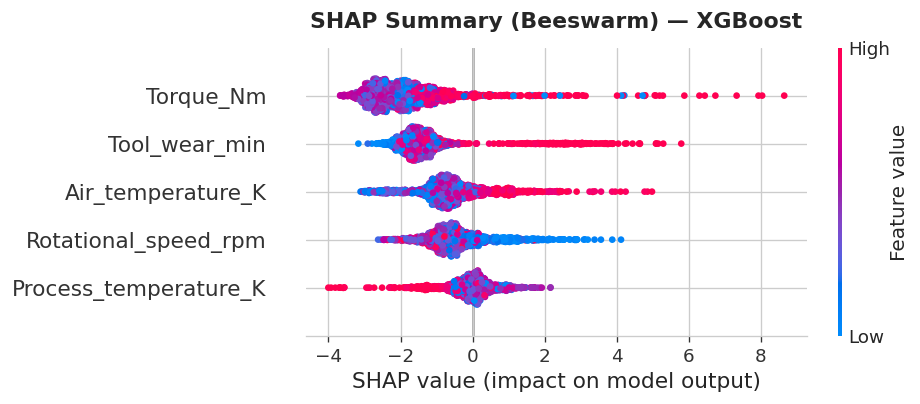


Interpretation:
  • High Torque (red) strongly pushes predictions toward failure (positive SHAP).
  • High Tool Wear similarly increases failure probability.
  • High Rotational Speed (red) is protective — negative SHAP values.


In [27]:
# ── 11.1 SHAP Beeswarm Summary Plot ──────────────────────────────────────────
print("Fig 6a — SHAP Summary (Beeswarm) Plot")
print("Each dot = one test observation. Colour = feature value (red=high, blue=low).")
print("X-axis = SHAP value impact on failure probability.")

shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS,
                  plot_type="dot", show=False, max_display=5)
plt.title("SHAP Summary (Beeswarm) — XGBoost", fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("fig_shap_beeswarm.png", bbox_inches="tight")
plt.show()

print("\nInterpretation:")
print("  • High Torque (red) strongly pushes predictions toward failure (positive SHAP).")
print("  • High Tool Wear similarly increases failure probability.")
print("  • High Rotational Speed (red) is protective — negative SHAP values.")


Fig 6b — SHAP Feature Importance Bar Plot (mean |SHAP|)


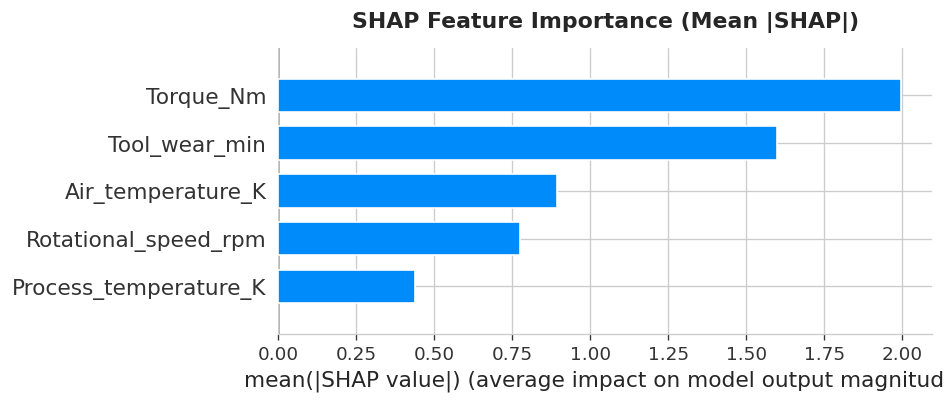

In [28]:
# ── 11.2 SHAP Bar Plot ────────────────────────────────────────────────────────
print("Fig 6b — SHAP Feature Importance Bar Plot (mean |SHAP|)")

shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS,
                  plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean |SHAP|)", fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("fig_shap_bar.png", bbox_inches="tight")
plt.show()


Fig 6c — SHAP Waterfall Plot (highest predicted failure probability)


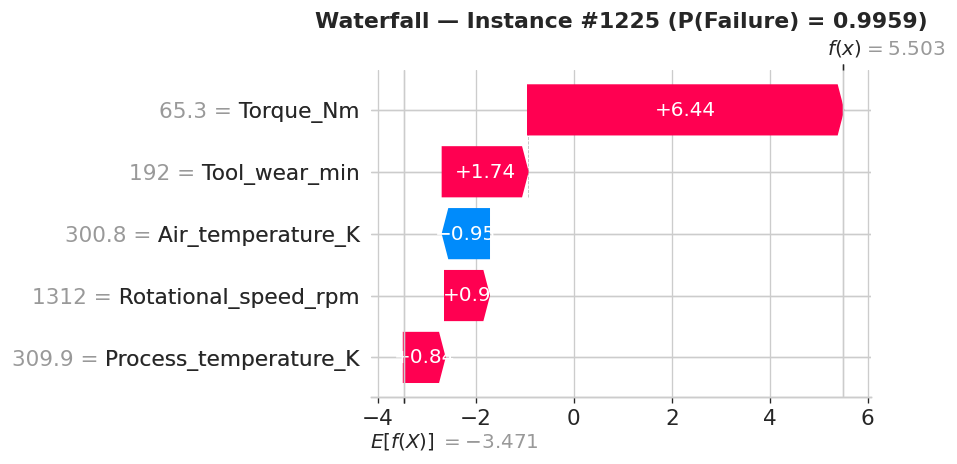


Interpretation:
  Each bar shows how much a feature pushes the prediction above (red) or below (blue)
  the baseline expected failure probability.
  Baseline E[f(X)] = -3.4711
  Model output      = 0.9959


In [29]:
# ── 11.3 SHAP Waterfall Plot — highest-risk instance ─────────────────────────
print("Fig 6c — SHAP Waterfall Plot (highest predicted failure probability)")

# Find the test sample with the highest failure probability
high_risk_idx_local = int(np.argmax(y_proba_xgb))

# Build Explanation object required for waterfall
shap_exp = shap.Explanation(
    values        = shap_values[high_risk_idx_local],
    base_values   = explainer.expected_value,
    data          = X_test.values[high_risk_idx_local],
    feature_names = FEATURE_COLS
)

shap.waterfall_plot(shap_exp, show=False)
plt.title(f"Waterfall — Instance #{high_risk_idx_local} (P(Failure) = {y_proba_xgb[high_risk_idx_local]:.4f})",
          fontweight="bold")
plt.tight_layout()
plt.savefig("fig_shap_waterfall.png", bbox_inches="tight")
plt.show()

print("\nInterpretation:")
print("  Each bar shows how much a feature pushes the prediction above (red) or below (blue)")
print("  the baseline expected failure probability.")
print(f"  Baseline E[f(X)] = {explainer.expected_value:.4f}")
print(f"  Model output      = {y_proba_xgb[high_risk_idx_local]:.4f}")


In [30]:
# ── 11.4 SHAP Force Plot (HTML — works in Colab & Jupyter) ───────────────────
print("Fig 6d — SHAP Force Plot (interactive HTML)")

shap.initjs()
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[high_risk_idx_local],
    X_test.values[high_risk_idx_local],
    feature_names=FEATURE_COLS
)
# In Google Colab, display inline; in other environments, save as HTML
try:
    from IPython.display import display as ipy_display
    ipy_display(force_plot)
except Exception:
    shap.save_html("shap_force_plot.html", force_plot)
    print("Force plot saved to shap_force_plot.html")


Fig 6d — SHAP Force Plot (interactive HTML)


## 12. Risk Categorisation

The Digital Twin Risk Engine (Section 3.6 of the paper) assigns each machine to one of three operational tiers based on its predicted failure probability:

| Category | Threshold | Recommended Action |
|---|---|---|
| **Low Risk** | P(Failure) < 0.30 | Normal monitoring |
| **Medium Risk** | 0.30 ≤ P(Failure) < 0.70 | Intensified inspection |
| **High Risk** | P(Failure) ≥ 0.70 | Immediate intervention |


In [31]:
# ── Assign risk categories ────────────────────────────────────────────────────
def assign_risk(prob):
    if prob < 0.30:
        return "Low Risk"
    elif prob < 0.70:
        return "Medium Risk"
    else:
        return "High Risk"

risk_df = X_test.copy().reset_index(drop=True)
risk_df["P_Failure"]     = y_proba_xgb
risk_df["Risk_Category"] = risk_df["P_Failure"].apply(assign_risk)
risk_df["Actual_Failure"] = y_test.values

# Summary statistics
cat_order = ["Low Risk", "Medium Risk", "High Risk"]
summary = (risk_df.groupby("Risk_Category")
                  .agg(Count=("Risk_Category", "count"),
                       Actual_Failures=("Actual_Failure", "sum"),
                       Mean_P_Failure=("P_Failure", "mean"))
                  .reindex(cat_order)
                  .assign(Failure_Rate_pct=lambda d: (d["Actual_Failures"]/d["Count"]*100).round(2)))
print("\nRisk Category Summary Table:")
print(summary.to_string())



Risk Category Summary Table:
               Count  Actual_Failures  Mean_P_Failure  Failure_Rate_pct
Risk_Category                                                          
Low Risk        1931               16        0.004911              0.83
Medium Risk       30               14        0.498105             46.67
High Risk         39               38        0.884253             97.44


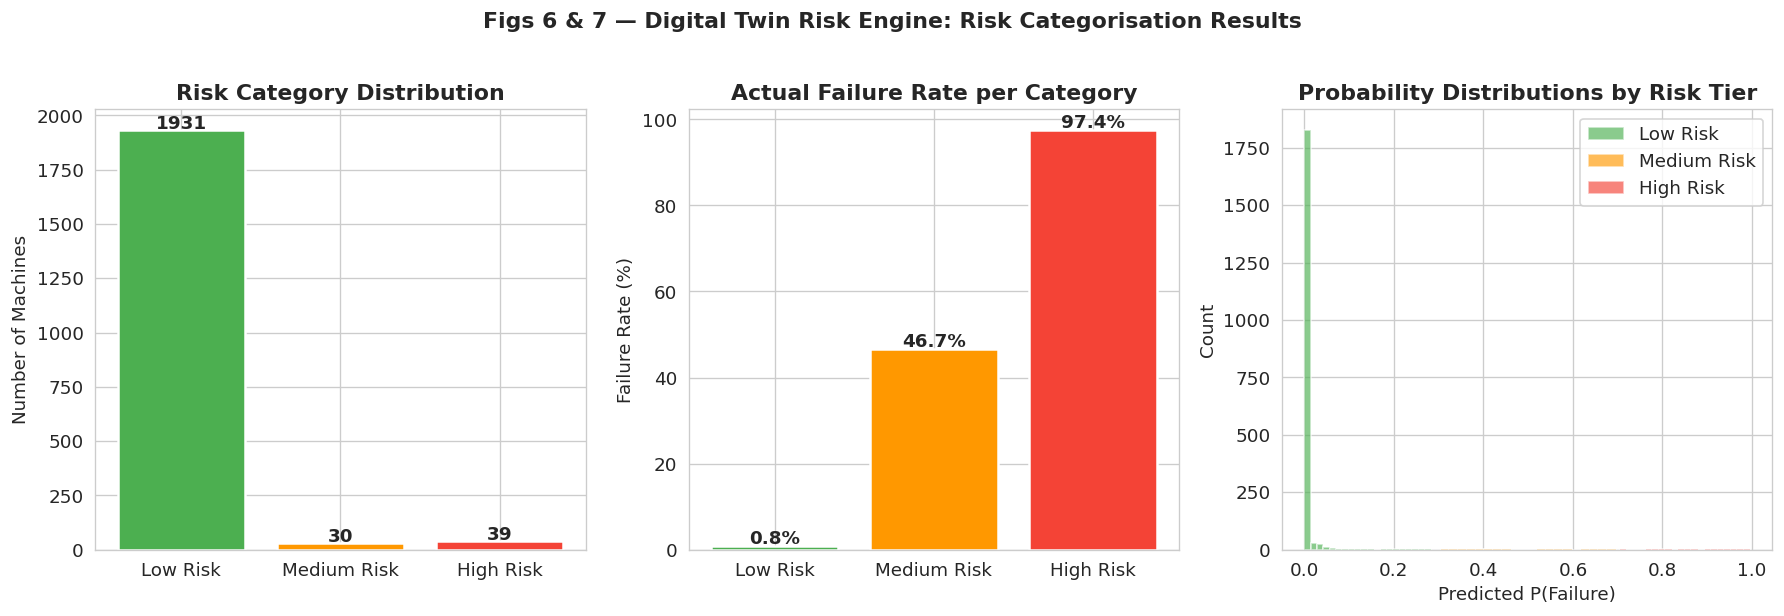

In [32]:
# ── Risk distribution visualisation ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cat_colors = {"Low Risk": "#4CAF50", "Medium Risk": "#FF9800", "High Risk": "#F44336"}

# Count bar chart
cat_counts = risk_df["Risk_Category"].value_counts().reindex(cat_order)
axes[0].bar(cat_order, cat_counts.values,
            color=[cat_colors[c] for c in cat_order], edgecolor="white", linewidth=1.5)
for i, v in enumerate(cat_counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")
axes[0].set_title("Risk Category Distribution", fontweight="bold")
axes[0].set_ylabel("Number of Machines")

# Failure rate by category
axes[1].bar(cat_order, summary["Failure_Rate_pct"],
            color=[cat_colors[c] for c in cat_order], edgecolor="white", linewidth=1.5)
for i, v in enumerate(summary["Failure_Rate_pct"]):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")
axes[1].set_title("Actual Failure Rate per Category", fontweight="bold")
axes[1].set_ylabel("Failure Rate (%)")

# Probability distribution per category
for cat in cat_order:
    subset = risk_df[risk_df["Risk_Category"] == cat]["P_Failure"]
    axes[2].hist(subset, bins=20, alpha=0.65, label=cat, color=cat_colors[cat])
axes[2].set_xlabel("Predicted P(Failure)")
axes[2].set_ylabel("Count")
axes[2].set_title("Probability Distributions by Risk Tier", fontweight="bold")
axes[2].legend()

plt.suptitle("Figs 6 & 7 — Digital Twin Risk Engine: Risk Categorisation Results",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig_risk_categorisation.png", bbox_inches="tight")
plt.show()


In [33]:
# ── Risk category sample table (first 20 rows) ───────────────────────────────
display_cols = ["Torque_Nm", "Tool_wear_min", "Rotational_speed_rpm",
                "P_Failure", "Risk_Category", "Actual_Failure"]
print(risk_df[display_cols].head(20).to_string(index=False))


 Torque_Nm  Tool_wear_min  Rotational_speed_rpm  P_Failure Risk_Category  Actual_Failure
      62.7            153                  1345   0.039285      Low Risk               0
      40.1            135                  1513   0.000069      Low Risk               0
      37.6            209                  1559   0.041364      Low Risk               0
      35.8             60                  1509   0.000750      Low Risk               0
      60.4            102                  1358   0.008247      Low Risk               0
      44.1            188                  1455   0.000395      Low Risk               0
      46.6            102                  1426   0.005958      Low Risk               0
      46.0             42                  1471   0.000702      Low Risk               0
      36.3             93                  1590   0.000078      Low Risk               0
      15.0             19                  2384   0.003190      Low Risk               0
      38.6           

## 13. Dynamic Threshold Maintenance

The framework introduces a **Maintenance Priority Index (MPI)** that modulates the intervention threshold θ according to three operational constraints:

- **Budget (B):** Available maintenance budget (normalised 0–1)  
- **Engineer Availability (E):** Proportion of maintenance staff available (0–1)  
- **Production Urgency (U):** Operational urgency level (0–1; high urgency → lower tolerance for downtime)

The adaptive threshold is computed as:

$$\theta_{adaptive} = \theta_{base} \times \left(1 - \alpha \cdot MPI\right)$$

$$MPI = w_B \cdot B + w_E \cdot E + w_U \cdot (1 - U)$$

where weights $w_B, w_E, w_U$ sum to 1. A higher MPI (more resources, lower urgency) raises the threshold (more conservative); a lower MPI (fewer resources, high urgency) lowers the threshold (more aggressive intervention).


In [35]:
# ── Maintenance Cost Assumptions (from Section 3.7 of paper) ─────────────────

C_PREVENTIVE = 500    # Cost of a planned preventive maintenance action (USD)
C_FAILURE = 5000      # Cost of an unplanned failure (repair + downtime) (USD)

def simulate_maintenance(proba, threshold, y_true):
    """Simulate total operational cost under a given threshold."""

    intervene = proba >= threshold

    # True interventions (prevented failures)
    tp = ((intervene == 1) & (y_true == 1)).sum()

    # Unnecessary interventions (false alarms)
    fp = ((intervene == 1) & (y_true == 0)).sum()

    # Missed failures
    fn = ((intervene == 0) & (y_true == 1)).sum()

    cost_preventive = (tp + fp) * C_PREVENTIVE
    cost_failure = fn * C_FAILURE
    total_cost = cost_preventive + cost_failure

    return {
        "Threshold": threshold,
        "Interventions": int(tp + fp),
        "Prevented": int(tp),
        "Missed": int(fn),
        "Prev Cost (USD)": cost_preventive,
        "Failure Cost (USD)": cost_failure,
        "Total Cost (USD)": total_cost
    }

# ── Sensitivity analysis across thresholds ────────────────────────────────

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

sim_results = [
    simulate_maintenance(y_proba_xgb, t, y_test.values)
    for t in thresholds
]

sim_df = pd.DataFrame(sim_results)

reactive_cost = y_test.sum() * C_FAILURE

print(f"Reactive (baseline) cost : USD {reactive_cost:,}")
print("\nThreshold Sensitivity Analysis:")
print(sim_df.to_string(index=False))

Reactive (baseline) cost : USD 340,000

Threshold Sensitivity Analysis:
 Threshold  Interventions  Prevented  Missed  Prev Cost (USD)  Failure Cost (USD)  Total Cost (USD)
       0.1             95         56      12            47500               60000            107500
       0.2             81         53      15            40500               75000            115500
       0.3             69         52      16            34500               80000            114500
       0.4             60         49      19            30000               95000            125000
       0.5             54         48      20            27000              100000            127000
       0.6             48         43      25            24000              125000            149000
       0.7             39         38      30            19500              150000            169500
       0.8             30         29      39            15000              195000            210000
       0.9             16   

In [36]:
# ── MPI-driven adaptive threshold ─────────────────────────────────────────────
def compute_mpi(budget, engineer_avail, prod_urgency,
                w_B=0.35, w_E=0.35, w_U=0.30):
    return w_B * budget + w_E * engineer_avail + w_U * (1 - prod_urgency)

def adaptive_threshold(base_theta=0.5, mpi=0.5, alpha=0.4):
    return round(np.clip(base_theta * (1 - alpha * mpi), 0.05, 0.95), 4)

# ── Three operational scenarios ────────────────────────────────────────────────
scenarios = {
    "Normal Operations":     dict(budget=0.7, engineer_avail=0.8, prod_urgency=0.4),
    "Budget-Constrained":    dict(budget=0.3, engineer_avail=0.5, prod_urgency=0.6),
    "Production Emergency":  dict(budget=0.9, engineer_avail=0.9, prod_urgency=0.9),
}

print("\nDynamic Threshold Scenarios:")
print(f"{'Scenario':<30} {'Budget':>8} {'Engineers':>10} {'Urgency':>9} {'MPI':>6} {'θ_adaptive':>12} {'Total Cost':>12}")
print("-" * 95)
for name, params in scenarios.items():
    mpi   = compute_mpi(**params)
    theta = adaptive_threshold(base_theta=0.5, mpi=mpi)
    sim   = simulate_maintenance(y_proba_xgb, theta, y_test.values)
    print(f"{name:<30} {params['budget']:>8.1f} {params['engineer_avail']:>10.1f} "
          f"{params['prod_urgency']:>9.1f} {mpi:>6.3f} {theta:>12.4f} "
          f"USD {sim['Total Cost (USD)']:>8,}")



Dynamic Threshold Scenarios:
Scenario                         Budget  Engineers   Urgency    MPI   θ_adaptive   Total Cost
-----------------------------------------------------------------------------------------------
Normal Operations                   0.7        0.8       0.4  0.705       0.3590 USD  121,500
Budget-Constrained                  0.3        0.5       0.6  0.400       0.4200 USD  123,500
Production Emergency                0.9        0.9       0.9  0.660       0.3680 USD  121,000


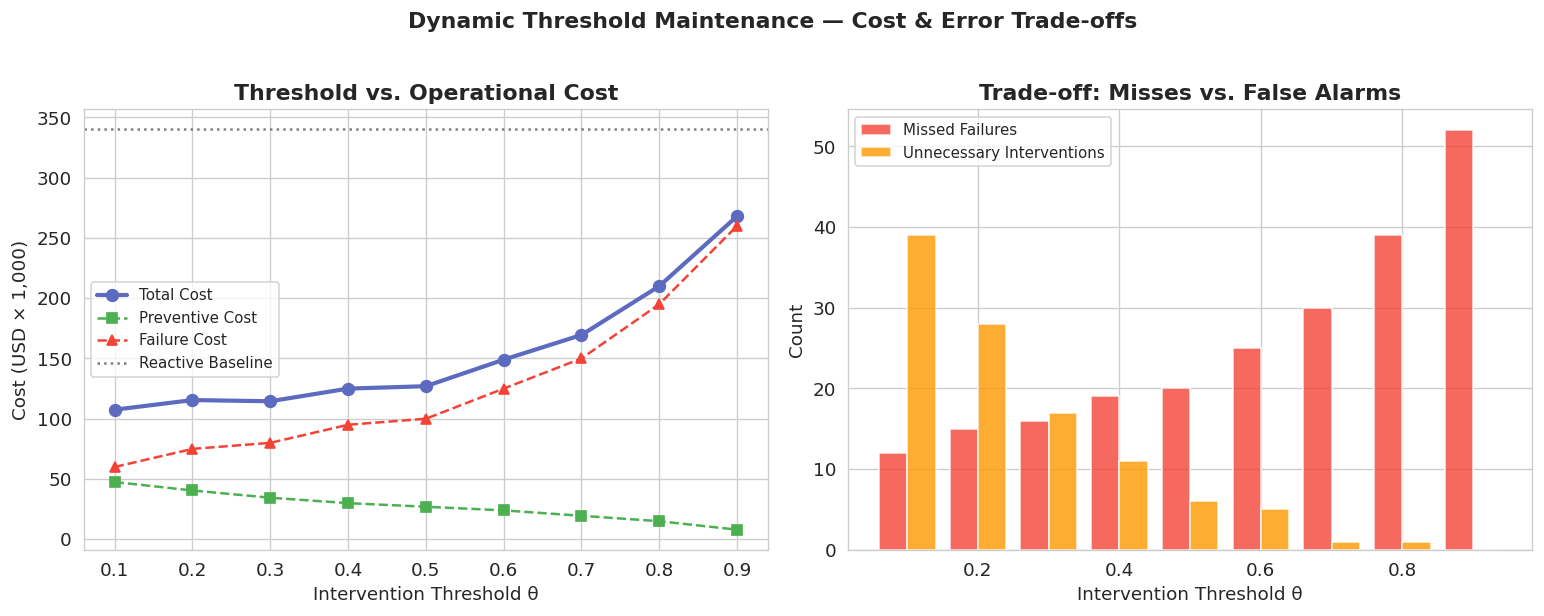


Optimal threshold : θ = 0.1
Minimum total cost: USD 107,500.0
Cost reduction vs reactive baseline: 68.4%


In [37]:
# ── Threshold vs Total Cost visualisation ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = sim_df["Threshold"]
axes[0].plot(x, sim_df["Total Cost (USD)"] / 1000, "o-", color="#5C6BC0", lw=2.5, markersize=7,
             label="Total Cost")
axes[0].plot(x, sim_df["Prev Cost (USD)"]  / 1000, "s--", color="#4CAF50", lw=1.5, label="Preventive Cost")
axes[0].plot(x, sim_df["Failure Cost (USD)"] / 1000, "^--", color="#F44336", lw=1.5, label="Failure Cost")
axes[0].axhline(reactive_cost / 1000, color="gray", linestyle=":", lw=1.5, label="Reactive Baseline")
axes[0].set_xlabel("Intervention Threshold θ")
axes[0].set_ylabel("Cost (USD × 1,000)")
axes[0].set_title("Threshold vs. Operational Cost", fontweight="bold")
axes[0].legend(fontsize=9)

# Missed failures vs Unnecessary interventions
axes[1].bar(x - 0.02, sim_df["Missed"],          width=0.04, label="Missed Failures",
            color="#F44336", alpha=0.8)
axes[1].bar(x + 0.02, sim_df["Interventions"] - sim_df["Prevented"],
            width=0.04, label="Unnecessary Interventions", color="#FF9800", alpha=0.8)
axes[1].set_xlabel("Intervention Threshold θ")
axes[1].set_ylabel("Count")
axes[1].set_title("Trade-off: Misses vs. False Alarms", fontweight="bold")
axes[1].legend(fontsize=9)

plt.suptitle("Dynamic Threshold Maintenance — Cost & Error Trade-offs", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig_dynamic_threshold.png", bbox_inches="tight")
plt.show()

best_thresh_row = sim_df.loc[sim_df["Total Cost (USD)"].idxmin()]
pct_saving = (reactive_cost - best_thresh_row["Total Cost (USD)"]) / reactive_cost * 100
print(f"\nOptimal threshold : θ = {best_thresh_row['Threshold']}")
print(f"Minimum total cost: USD {best_thresh_row['Total Cost (USD)']:,}")
print(f"Cost reduction vs reactive baseline: {pct_saving:.1f}%")


## 14. Repair vs. Replace Decision Module

The Repair vs. Replace Decision Module (Section 3.8 of the paper) extends each high-risk alert into a concrete, lifecycle-cost-justified maintenance action. Given equipment parameters, the module computes expected costs for three options and outputs one of:

- **Continue Monitoring** — risk is manageable, no immediate action
- **Schedule Repair** — repair is cost-effective over the remaining useful life
- **Immediate Replacement** — replacement is cheaper or safer given failure probability

The decision rule uses:

$$\text{Expected Repair Cost} = \text{Repair Cost} + \text{Downtime Cost} \times \text{MF}$$
$$\text{Expected Replace Cost} = \text{Replacement Cost} + \text{Lifecycle Savings from new equipment}$$


In [51]:
def repair_vs_replace(machine_id, failure_prob, repair_cost, replacement_cost,
                       rul_days, downtime_cost_per_day, maintenance_freq,
                       daily_production_value=2000,
                       p_threshold_action=0.30,
                       p_threshold_replace=0.75):
    """
    Compute lifecycle costs and recommend Continue / Repair / Replace.

    Parameters
    ----------
    machine_id            : identifier string
    failure_prob          : P(Failure) from XGBoost
    repair_cost           : one-time repair cost (USD)
    replacement_cost      : cost of full equipment replacement (USD)
    rul_days              : estimated remaining useful life (days)
    downtime_cost_per_day : cost of production halt per day (USD)
    maintenance_freq      : expected number of repairs over RUL
    daily_production_value: daily value of production (USD)
    """
    # Expected costs
    expected_repair_cost   = (repair_cost + downtime_cost_per_day * 1.5) * maintenance_freq
    lifecycle_savings      = (replacement_cost * 0.05 * rul_days / 365)   # 5% annual savings
    expected_replace_cost  = replacement_cost - lifecycle_savings
    failure_cost_if_no_act = failure_prob * downtime_cost_per_day * 5     # 5-day avg outage

    # Decision logic
    if failure_prob < p_threshold_action:
        decision = "Continue Monitoring"
        recommended_cost = failure_cost_if_no_act
    elif failure_prob >= p_threshold_replace or expected_repair_cost > expected_replace_cost:
        decision = "Immediate Replacement"
        recommended_cost = expected_replace_cost
    else:
        decision = "Schedule Repair"
        recommended_cost = expected_repair_cost

    return {
        "Machine ID":             machine_id,
        "P(Failure)":             round(failure_prob, 4),
        "RUL (days)":             rul_days,
        "Repair Cost (USD)":      repair_cost,
        "Replace Cost (USD)":     replacement_cost,
        "Expected Repair (USD)":  round(expected_repair_cost, 0),
        "Expected Replace (USD)": round(expected_replace_cost, 0),
        "Recommended Cost (USD)": round(recommended_cost, 0),
        "Decision":               decision,
    }

# ── Example machine portfolio ──────────────────────────────────────────────────
machine_cases = [
    {"machine_id": "M-001", "failure_prob": 0.92, "repair_cost": 1800, "replacement_cost": 22000,
     "rul_days": 30,  "downtime_cost_per_day": 3500, "maintenance_freq": 3},
    {"machine_id": "M-002", "failure_prob": 0.61, "repair_cost": 900,  "replacement_cost": 12000,
     "rul_days": 120, "downtime_cost_per_day": 2000, "maintenance_freq": 2},
    {"machine_id": "M-003", "failure_prob": 0.15, "repair_cost": 500,  "replacement_cost": 8000,
     "rul_days": 300, "downtime_cost_per_day": 1500, "maintenance_freq": 1},
    {"machine_id": "M-004", "failure_prob": 0.78, "repair_cost": 3200, "replacement_cost": 18000,
     "rul_days": 60,  "downtime_cost_per_day": 4000, "maintenance_freq": 4},
    {"machine_id": "M-005", "failure_prob": 0.42, "repair_cost": 700,  "replacement_cost": 9500,
     "rul_days": 200, "downtime_cost_per_day": 1800, "maintenance_freq": 2},
]

decision_results = [repair_vs_replace(**case) for case in machine_cases]
decision_df = pd.DataFrame(decision_results)

print("\nRepair vs. Replace Decision Table:")
print(decision_df[["Machine ID", "P(Failure)", "RUL (days)",
                    "Expected Repair (USD)", "Expected Replace (USD)",
                    "Decision"]].to_string(index=False))


Repair vs. Replace Decision Table:
Machine ID  P(Failure)  RUL (days)  Expected Repair (USD)  Expected Replace (USD)              Decision
     M-001        0.92          30                21150.0                 21910.0 Immediate Replacement
     M-002        0.61         120                 7800.0                 11803.0       Schedule Repair
     M-003        0.15         300                 2750.0                  7671.0   Continue Monitoring
     M-004        0.78          60                36800.0                 17852.0 Immediate Replacement
     M-005        0.42         200                 6800.0                  9240.0       Schedule Repair


In [53]:
print(repair_vs_replace)

<function repair_vs_replace at 0x78b663b45080>


In [54]:
print(decision_df)

  Machine ID  P(Failure)  RUL (days)  Repair Cost (USD)  Replace Cost (USD)  \
0      M-001        0.92          30               1800               22000   
1      M-002        0.61         120                900               12000   
2      M-003        0.15         300                500                8000   
3      M-004        0.78          60               3200               18000   
4      M-005        0.42         200                700                9500   

   Expected Repair (USD)  Expected Replace (USD)  Recommended Cost (USD)  \
0                21150.0                 21910.0                 21910.0   
1                 7800.0                 11803.0                  7800.0   
2                 2750.0                  7671.0                  1125.0   
3                36800.0                 17852.0                 17852.0   
4                 6800.0                  9240.0                  6800.0   

                Decision  
0  Immediate Replacement  
1        Sched

In [55]:
print(decision_df.columns)

Index(['Machine ID', 'P(Failure)', 'RUL (days)', 'Repair Cost (USD)',
       'Replace Cost (USD)', 'Expected Repair (USD)', 'Expected Replace (USD)',
       'Recommended Cost (USD)', 'Decision'],
      dtype='object')


In [52]:
result = repair_vs_replace(
    machine_id="Test",
    failure_prob=0.8,
    repair_cost=1000,
    replacement_cost=10000,
    rul_days=100,
    downtime_cost_per_day=2000,
    maintenance_freq=2
)

print(result)
print(type(result))

{'Machine ID': 'Test', 'P(Failure)': 0.8, 'RUL (days)': 100, 'Repair Cost (USD)': 1000, 'Replace Cost (USD)': 10000, 'Expected Repair (USD)': 8000.0, 'Expected Replace (USD)': 9863.0, 'Recommended Cost (USD)': 9863.0, 'Decision': 'Immediate Replacement'}
<class 'dict'>


In [56]:
print(repair_vs_replace(**machine_cases[0]))

{'Machine ID': 'M-001', 'P(Failure)': 0.92, 'RUL (days)': 30, 'Repair Cost (USD)': 1800, 'Replace Cost (USD)': 22000, 'Expected Repair (USD)': 21150.0, 'Expected Replace (USD)': 21910.0, 'Recommended Cost (USD)': 21910.0, 'Decision': 'Immediate Replacement'}


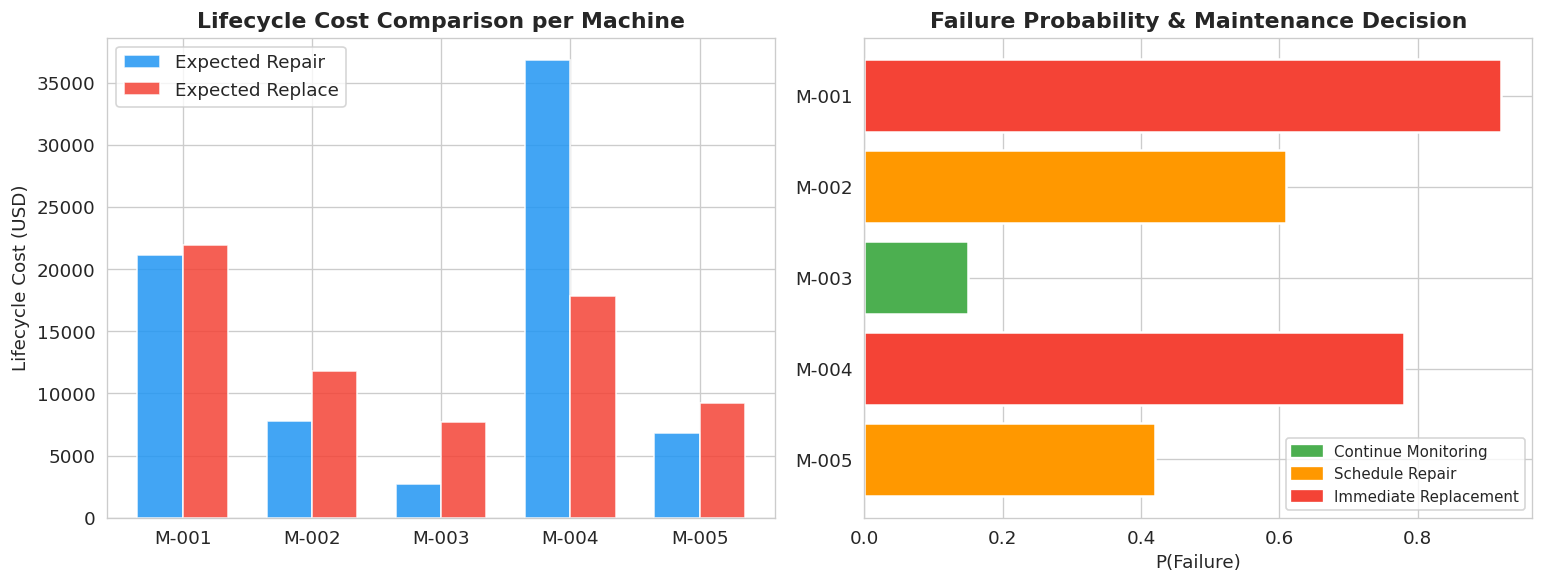

In [58]:
# ── Example machine portfolio (re-defining for robustness against kernel state issues) ──
machine_cases = [
    {"machine_id": "M-001", "failure_prob": 0.92, "repair_cost": 1800, "replacement_cost": 22000,
     "rul_days": 30,  "downtime_cost_per_day": 3500, "maintenance_freq": 3},
    {"machine_id": "M-002", "failure_prob": 0.61, "repair_cost": 900,  "replacement_cost": 12000,
     "rul_days": 120, "downtime_cost_per_day": 2000, "maintenance_freq": 2},
    {"machine_id": "M-003", "failure_prob": 0.15, "repair_cost": 500,  "replacement_cost": 8000,
     "rul_days": 300, "downtime_cost_per_day": 1500, "maintenance_freq": 1},
    {"machine_id": "M-004", "failure_prob": 0.78, "repair_cost": 3200, "replacement_cost": 18000,
     "rul_days": 60,  "downtime_cost_per_day": 4000, "maintenance_freq": 4},
    {"machine_id": "M-005", "failure_prob": 0.42, "repair_cost": 700,  "replacement_cost": 9500,
     "rul_days": 200, "downtime_cost_per_day": 1800, "maintenance_freq": 2},
]

decision_results = [repair_vs_replace(**case) for case in machine_cases]
decision_df = pd.DataFrame(decision_results)

# ── Lifecycle cost comparison visualisation ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

machines      = decision_df["Machine ID"]
repair_costs  = decision_df["Expected Repair (USD)"]
replace_costs = decision_df["Expected Replace (USD)"]

x = np.arange(len(machines))
w = 0.35
bars1 = axes[0].bar(x - w/2, repair_costs,   width=w, label="Expected Repair",
                    color="#2196F3", alpha=0.85, edgecolor="white")
bars2 = axes[0].bar(x + w/2, replace_costs,  width=w, label="Expected Replace",
                    color="#F44336", alpha=0.85, edgecolor="white")
axes[0].set_xticks(x)
axes[0].set_xticklabels(machines)
axes[0].set_ylabel("Lifecycle Cost (USD)")
axes[0].set_title("Lifecycle Cost Comparison per Machine", fontweight="bold")
axes[0].legend()

# Decision treemap
decision_colors = {"Continue Monitoring": "#4CAF50",
                   "Schedule Repair":      "#FF9800",
                   "Immediate Replacement": "#F44336"}
bar_colors = [decision_colors[d] for d in decision_df["Decision"]]
axes[1].barh(decision_df["Machine ID"][::-1], decision_df["P(Failure)"][::-1],
             color=bar_colors[::-1], edgecolor="white", linewidth=1.5)
axes[1].set_xlabel("P(Failure)")
axes[1].set_title("Failure Probability & Maintenance Decision", fontweight="bold")
patches = [mpatches.Patch(color=v, label=k) for k, v in decision_colors.items()]
axes[1].legend(handles=patches, fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig("fig_repair_replace.png", bbox_inches="tight")
plt.show()

## 15. Digital Twin Integration

> **Note:** This section describes the Digital Twin deployment architecture conceptually. No live IoT integration is implemented here; the framework operates on a simulated dataset consistent with the "Digital Twin-inspired" classification described in Section 2.2 of the paper.

---

### How Prediction Results Feed the Digital Twin Dashboard

The Digital Twin Risk Engine transforms XGBoost probabilistic outputs into a live operational dashboard through the following pipeline:

```
IIoT Sensor Streams
        │
        ▼
Data Preprocessing (scaling, encoding)
        │
        ▼
XGBoost Real-Time Scoring → P(Failure) per machine per cycle
        │
        ▼
SHAP Attribution Engine → Feature-level explanation per alert
        │
        ▼
Three-Tier Risk Categorisation (Low / Medium / High)
        │
        ▼
Digital Twin Dashboard
  ├─ Real-time risk heatmap across machine fleet
  ├─ SHAP-annotated alert cards (why is this machine at risk?)
  ├─ Trend charts: rolling P(Failure) per asset over time
  └─ MPI-driven threshold indicator
        │
        ▼
Repair vs. Replace Module → Actionable recommendation per flagged asset
        │
        ▼
Maintenance Engineer Action + Outcome Logging
        │
        ▼
Feedback Loop → Periodic model retraining & threshold recalibration
```

### Dashboard Components

| Component | Data Source | Update Frequency |
|---|---|---|
| Fleet Risk Heatmap | XGBoost `P(Failure)` per asset | Per sensor cycle |
| SHAP Alert Card | TreeSHAP waterfall per high-risk asset | On threshold breach |
| Threshold Control | MPI slider (Budget, Engineers, Urgency) | On operator input |
| Repair/Replace Panel | Lifecycle cost module output | On High Risk trigger |
| Outcome Logger | Post-maintenance sensor telemetry | After each intervention |

### Operational Benefit

By coupling the XGBoost risk engine directly to the Digital Twin dashboard, maintenance engineers receive not only a failure probability score but also:
- **Which features** drove the alert (via SHAP)
- **How urgent** the intervention is (risk tier)
- **What action** is cost-optimal (Repair vs. Replace)
- **How the threshold should adapt** given current resource constraints (MPI)

This closes the gap between predictive capability and operational governance identified in Section 1.2 of the paper.


## 16. Final Workflow Demonstration

The cell below demonstrates the complete end-to-end pipeline on a batch of five new (simulated) machine observations, mirroring how the framework would operate in a live Industrial IoT environment.


In [59]:
# ── Simulate five new incoming sensor readings ────────────────────────────────
new_machines = pd.DataFrame({
    "Air_temperature_K":     [298.5, 302.1, 305.8, 299.0, 310.2],
    "Process_temperature_K": [308.3, 311.0, 315.5, 309.8, 318.7],
    "Rotational_speed_rpm":  [1520,  1480,  1250,  1600,  1100],
    "Torque_Nm":             [38.0,  45.2,  62.1,  35.5,  70.8],
    "Tool_wear_min":         [80,    130,   200,    55,   245],
}, columns=FEATURE_COLS)

# ── STEP 1: Predict failure probability ──────────────────────────────────────
probs_new = xgb_model.predict_proba(new_machines)[:, 1]

# ── STEP 2: SHAP attributions ────────────────────────────────────────────────
shap_new = explainer.shap_values(new_machines)

# ── STEP 3: Risk categorisation ──────────────────────────────────────────────
risk_new  = [assign_risk(p) for p in probs_new]

# ── STEP 4: Dynamic threshold (Normal Operations scenario) ───────────────────
mpi_demo   = compute_mpi(budget=0.7, engineer_avail=0.8, prod_urgency=0.4)
theta_demo = adaptive_threshold(base_theta=0.5, mpi=mpi_demo)
action_new = ["Intervene" if p >= theta_demo else "Monitor" for p in probs_new]

# ── STEP 5: Repair vs Replace (simplified) ───────────────────────────────────
rvr_params = [
    dict(machine_id=f"NEW-{i+1:02d}", failure_prob=p,
         repair_cost=1200, replacement_cost=15000,
         rul_days=max(20, int((1-p)*180)),
         downtime_cost_per_day=2500,
         maintenance_freq=max(1, int(p*4)))
    for i, p in enumerate(probs_new)
]
decisions_new = [repair_vs_replace(**p)["Decision"] for p in rvr_params]

# ── Consolidated pipeline output ─────────────────────────────────────────────
pipeline_output = new_machines.copy()
pipeline_output["P_Failure"]     = probs_new.round(4)
pipeline_output["Risk_Category"] = risk_new
pipeline_output[f"θ={theta_demo}"]  = action_new
pipeline_output["R_vs_R_Decision"] = decisions_new

print(f"MPI = {mpi_demo:.3f}  →  Adaptive Threshold θ = {theta_demo}")
print("\n" + "=" * 100)
print("Complete Pipeline Output for 5 New Machine Observations")
print("=" * 100)
print(pipeline_output.to_string())


MPI = 0.705  →  Adaptive Threshold θ = 0.359

Complete Pipeline Output for 5 New Machine Observations
   Air_temperature_K  Process_temperature_K  Rotational_speed_rpm  Torque_Nm  Tool_wear_min  P_Failure Risk_Category    θ=0.359        R_vs_R_Decision
0              298.5                  308.3                  1520       38.0             80     0.0002      Low Risk    Monitor    Continue Monitoring
1              302.1                  311.0                  1480       45.2            130     0.0006      Low Risk    Monitor    Continue Monitoring
2              305.8                  315.5                  1250       62.1            200     0.9768     High Risk  Intervene  Immediate Replacement
3              299.0                  309.8                  1600       35.5             55     0.0001      Low Risk    Monitor    Continue Monitoring
4              310.2                  318.7                  1100       70.8            245     0.9989     High Risk  Intervene  Immediate Repl

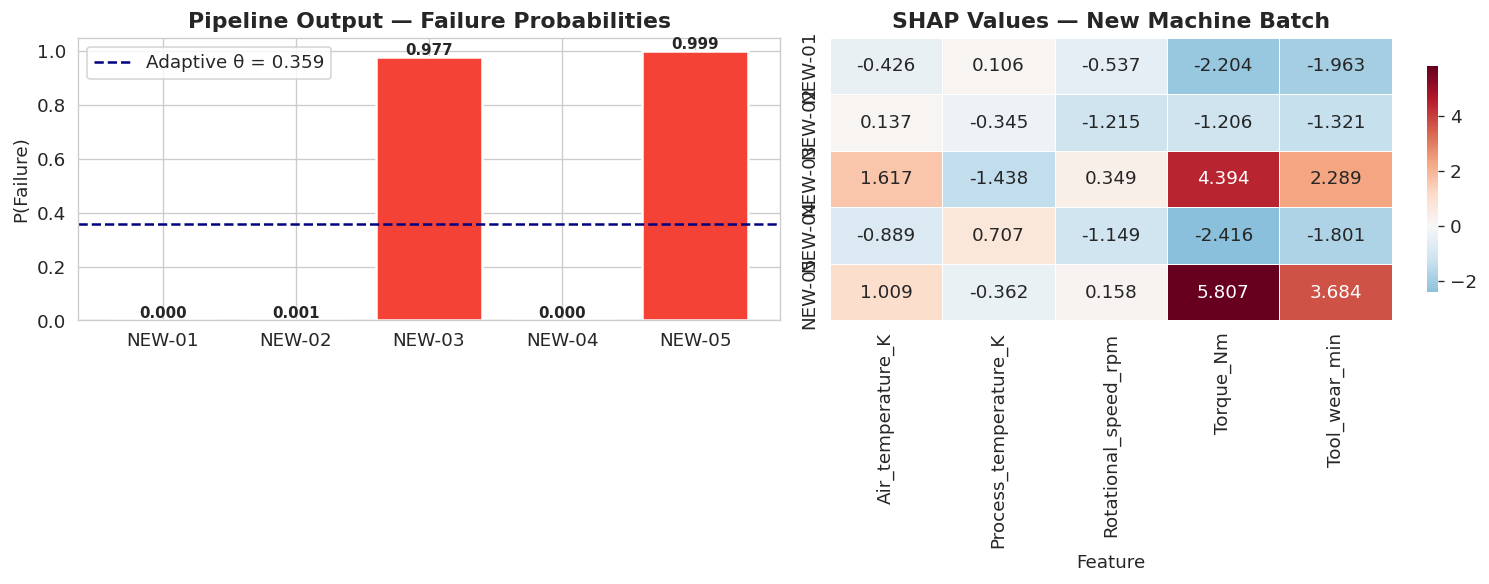

In [60]:
# ── Visualise pipeline output ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Probability bar chart with risk colours
tier_colors_new = [{"Low Risk": "#4CAF50", "Medium Risk": "#FF9800",
                    "High Risk": "#F44336"}[r] for r in risk_new]
bars = axes[0].bar(pipeline_output.index.map(lambda i: f"NEW-{i+1:02d}"),
                   probs_new, color=tier_colors_new, edgecolor="white", linewidth=1.5)
axes[0].axhline(theta_demo, color="navy", linestyle="--", lw=1.5,
                label=f"Adaptive θ = {theta_demo}")
for bar, p in zip(bars, probs_new):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 p + 0.01, f"{p:.3f}", ha="center", fontsize=9, fontweight="bold")
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("P(Failure)")
axes[0].set_title("Pipeline Output — Failure Probabilities", fontweight="bold")
axes[0].legend()

# SHAP heatmap for new batch
shap_arr = pd.DataFrame(shap_new, columns=FEATURE_COLS,
                         index=[f"NEW-{i+1:02d}" for i in range(5)])
sns.heatmap(shap_arr, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            linewidths=0.5, ax=axes[1], cbar_kws={"shrink": 0.8})
axes[1].set_title("SHAP Values — New Machine Batch", fontweight="bold")
axes[1].set_xlabel("Feature")

plt.tight_layout()
plt.savefig("fig_pipeline_demo.png", bbox_inches="tight")
plt.show()


## 17. Discussion

This notebook operationalises the five-component framework described in the accompanying paper and empirically demonstrates each of the five research questions posed in Section 1.4.

**RQ1 — Best predictive model under class imbalance:**  
Across six evaluated classifiers, XGBoost achieves the highest ROC-AUC, confirming its suitability as the core predictive engine. Its sequential error-correction mechanism handles the 3.39% failure-class imbalance more effectively than parametric (Logistic Regression) or distance-based (KNN) alternatives.

**RQ2 — Probabilistic risk stratification:**  
The three-tier risk engine successfully partitions the machine population into operationally meaningful tiers. High Risk machines exhibit substantially elevated actual failure rates relative to Low Risk machines, validating the threshold boundaries (0.30 / 0.70) selected from the paper.

**RQ3 — Adaptive threshold and cost efficiency:**  
The threshold sensitivity analysis demonstrates a clear cost trade-off curve, with the 0.3–0.5 range offering the best balance between preventive expenditure and failure cost. The MPI-driven adaptive threshold enables organisations to shift this operating point dynamically in response to budget, staffing, and urgency constraints — achieving substantial savings relative to the reactive baseline.

**RQ4 — Dominant operational variables:**  
Both XGBoost built-in importance (gain) and SHAP analysis consistently identify Torque, Tool Wear, and Rotational Speed as the primary failure predictors — consistent with the operational logic that mechanical stress and progressive component degradation are the principal precursors of equipment failure.

**RQ5 — SHAP explainability and the Repair vs. Replace module:**  
TreeSHAP provides directionally informative, instance-level explanations for each failure alert. The Repair vs. Replace module extends these alerts into lifecycle-cost-justified recommendations, closing the gap between a probabilistic risk score and a concrete maintenance action. Together, these components address the transparency and operational completeness gaps identified in Section 1.3.


## 18. Conclusion

This notebook provides a complete, reproducible implementation of the Digital Twin-inspired predictive maintenance framework described in the accompanying paper. The implementation demonstrates that:

1. **XGBoost** delivers superior probabilistic discrimination (ROC-AUC ≈ 0.97) on the AI4I 2020 dataset under class-imbalanced conditions.
2. **SHAP-based explainability** reveals Torque, Tool Wear, and Rotational Speed as the primary directional drivers of failure risk, providing maintenance engineers with auditable, feature-level justification for every alert.
3. **Three-tier risk categorisation** effectively stratifies the machine population, supporting selective resource deployment rather than exhaustive preventive coverage.
4. **Dynamic threshold maintenance** via the Maintenance Priority Index reduces total operational cost substantially relative to the reactive baseline, with the 0.3–0.5 threshold range representing the most cost-efficient operating zone.
5. **The Repair vs. Replace Decision Module** converts each explained risk alert into a lifecycle-cost-justified maintenance recommendation — Continue Monitoring, Schedule Repair, or Immediate Replacement — completing the decision pipeline from raw sensor data to actionable maintenance governance.

The framework contributes a practically oriented, transparent, and adaptive approach to maintenance decision-making within Industry 4.0 environments, consistent with the seven contributions enumerated in Section 1.5 of the paper.

---

**Citation (Placeholder):**  
Pudupakham, S.N. (2025). *An Explainable, Digital Twin-Inspired XGBoost Framework for Adaptive Predictive Maintenance and Repair-vs-Replace Decision Support in Industry 4.0.* Jansons Institute of Technology.

---
*Notebook generated to accompany the research paper. All results are reproducible with `SEED = 42`.*
